# Friction Survival: Where the Edge Dies

**Docker image**: `ml4t`

This notebook cross-cuts the case studies by **failure mode**: gross-to-net
Sharpe degradation, breakeven cost thresholds, cadence-frequency vulnerability,
and cost-model realism caveats. Ch18 establishes the cost taxonomy and the
per-asset-class machinery; this notebook reads the resulting Ch18 cost-sweep
backtests directly out of each case study's registry and asks which
strategies survive the friction of real trading.

**Learning Objectives**:
- Quantify each strategy's sensitivity to per-leg friction on a common scale
- Identify breakeven cost thresholds per rebalance cadence
- Recognize when a generic basis-point sweep is the wrong cost model
  (single-name options, intraday equities)

**Book Reference**: Chapter 20, Section 20.6 (Trading Realism)

**Prerequisites**: Run [`01_aggregate_synthesis`](01_aggregate_synthesis.ipynb) first.
Each case study's registry must contain Ch18 `cost_sensitivity`-stage backtests.

In [1]:
"""Ch20 Friction Survival — cross-case-study cost-sweep analysis from registry."""

import warnings

import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Patch

from case_studies.utils.analytics import (
    CADENCE_MAP,
    CASE_STUDY_IDS,
    SHORT_NAMES,
    load_carrier_cost_curves,
)

warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(20)

polars.config.Config

In [2]:
MAX_CASE_STUDIES = 0  # 0 = all

In [3]:
CS_LIST = CASE_STUDY_IDS[:MAX_CASE_STUDIES] if MAX_CASE_STUDIES else CASE_STUDY_IDS

## Load Cost Sweep Results from Registry

Ch18 backtests vary commission + slippage across a grid of cost levels
while holding the signal and allocation constant. We read the sweep for
each case study's **deployed carrier** — the highest-validation-Sharpe
configuration across the signal, allocation, and risk-overlay stages —
so the breakeven measured here is the cost survival of the strategy the
chapter actually deploys, not of whichever allocator happened to be best
at zero cost. (NASDAQ-100's carrier is the cost-feasible ensemble built
in *§20.4*, pinned inside the loader.)

In [4]:
costs_df = load_carrier_cost_curves(CS_LIST)

if costs_df.is_empty():
    msg = "No Ch18 cost-sensitivity backtests found for any deployed carrier"
    raise RuntimeError(msg)

n_cs = costs_df["case_study"].n_unique()
print(f"Loaded {len(costs_df)} carrier cost-sweep entries across {n_cs} case studies")
costs_df.head(5)

Loaded 88 carrier cost-sweep entries across 8 case studies


case_study,label,allocator,cost_bps,sharpe,total_return,max_drawdown,display_name,cadence
str,str,str,f64,f64,f64,f64,str,str
"""cme_futures""","""fwd_ret_5d""","""inverse_vol""",0.0,1.289007,2.087177,-0.181685,"""CME Futures""","""monthly"""
"""cme_futures""","""fwd_ret_5d""","""inverse_vol""",1.0,1.265666,2.018637,-0.182656,"""CME Futures""","""monthly"""
"""cme_futures""","""fwd_ret_5d""","""inverse_vol""",2.0,1.240215,1.947488,-0.181233,"""CME Futures""","""monthly"""
"""cme_futures""","""fwd_ret_5d""","""inverse_vol""",3.0,1.213814,1.875951,-0.182362,"""CME Futures""","""monthly"""
"""cme_futures""","""fwd_ret_5d""","""inverse_vol""",5.0,1.17083,1.762539,-0.183056,"""CME Futures""","""monthly"""


## Gross-to-Net Sharpe Degradation

For each case study we compare the zero-cost (gross) Sharpe with the
Sharpe at the assumed cost level. This reveals how much performance
each dataset's cost structure consumes.

In [5]:
gross_df = costs_df.filter(pl.col("cost_bps") == 0)
net_df = costs_df.filter(pl.col("cost_bps") > 0)

# One allocator per case study (the carrier's); this selects it.
best_alloc = (
    gross_df.sort("sharpe", descending=True)
    .unique(subset=["case_study"], keep="first")
    .select("case_study", "allocator")
)

In [6]:
summary_rows = []
for row in best_alloc.iter_rows(named=True):
    cs = row["case_study"]
    alloc = row["allocator"]
    gross_row = gross_df.filter((pl.col("case_study") == cs) & (pl.col("allocator") == alloc))
    if gross_row.is_empty():
        continue
    gross_sharpe = gross_row["sharpe"][0]

    net_rows = net_df.filter((pl.col("case_study") == cs) & (pl.col("allocator") == alloc)).sort(
        "cost_bps"
    )

    if net_rows.is_empty():
        continue

    assumed = net_rows.row(0, named=True)
    net_sharpe = assumed["sharpe"]
    assumed_cost = assumed["cost_bps"]

    positive = net_rows.filter(pl.col("sharpe") > 0)
    breakeven_bps = int(positive["cost_bps"].max()) if not positive.is_empty() else 0

    summary_rows.append(
        {
            "case_study": cs,
            "display_name": SHORT_NAMES.get(cs, cs),
            "cadence": CADENCE_MAP.get(cs, "unknown"),
            "allocator": alloc,
            "gross_sharpe": round(gross_sharpe, 3),
            "net_sharpe": round(net_sharpe, 3),
            "sharpe_drag": round(gross_sharpe - net_sharpe, 3),
            "drag_pct": round(100 * (gross_sharpe - net_sharpe) / gross_sharpe, 1)
            if gross_sharpe != 0
            else 0.0,
            "assumed_cost_bps": assumed_cost,
            "breakeven_bps": breakeven_bps,
        }
    )

In [7]:
summary = pl.DataFrame(summary_rows).sort("drag_pct", descending=True)
print("=== Gross-to-Net Sharpe Degradation ===")
summary.select(
    "display_name",
    "cadence",
    "gross_sharpe",
    "net_sharpe",
    "sharpe_drag",
    "drag_pct",
    "assumed_cost_bps",
    "breakeven_bps",
)

=== Gross-to-Net Sharpe Degradation ===


display_name,cadence,gross_sharpe,net_sharpe,sharpe_drag,drag_pct,assumed_cost_bps,breakeven_bps
str,str,f64,f64,f64,f64,f64,i64
"""FX""","""daily""",0.324,0.283,0.041,12.8,1.0,7
"""NQ100""","""15-min""",1.164,1.074,0.089,7.7,1.0,10
"""Crypto""","""8-hourly""",3.497,3.332,0.165,4.7,1.0,15
"""SP500 Eq+Opt""","""monthly""",1.443,1.412,0.03,2.1,1.0,30
"""CME Futures""","""monthly""",1.289,1.266,0.023,1.8,1.0,30
"""US Equities""","""daily""",2.503,2.464,0.038,1.5,1.0,50
"""ETFs""","""monthly""",1.177,1.165,0.011,0.9,1.0,50
"""US Firms""","""monthly""",2.926,2.912,0.014,0.5,1.0,50


## Cost Drag Visualization

The horizontal bar chart shows Sharpe drag (gross minus net) for each
case study, ordered by severity. Higher-frequency strategies typically
suffer more because they accumulate turnover costs faster.

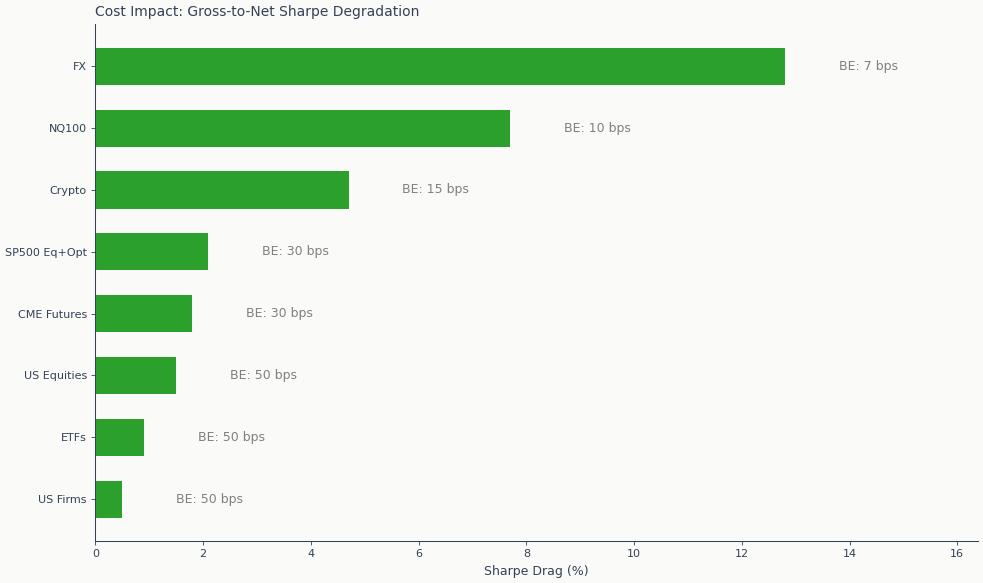

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "#d62728" if drag > 50 else "#ff7f0e" if drag > 20 else "#2ca02c"
    for drag in summary["drag_pct"]
]

bars = ax.barh(
    range(len(summary)),
    summary["drag_pct"].to_list(),
    color=colors,
    edgecolor="none",
    height=0.6,
)
ax.set_yticks(range(len(summary)))
ax.set_yticklabels(summary["display_name"].to_list())
ax.set_xlabel("Sharpe Drag (%)")
ax.set_title("Cost Impact: Gross-to-Net Sharpe Degradation")
ax.invert_yaxis()

for bar, bps in zip(bars, summary["breakeven_bps"].to_list(), strict=False):
    ax.annotate(
        f"BE: {bps} bps",
        xy=(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2),
        va="center",
        fontsize=9,
        color="gray",
    )
# Headroom so the breakeven annotation on the widest bar (FX) is not clipped.
ax.set_xlim(right=max(summary["drag_pct"]) * 1.28)

fig.tight_layout()
fig.show()

## Breakeven Cost Thresholds by Frequency

Breakeven cost is the maximum per-leg cost (in bps) at which the
deployed carrier still produces a positive Sharpe ratio. It is the cost
budget that the signal supports before becoming unprofitable.

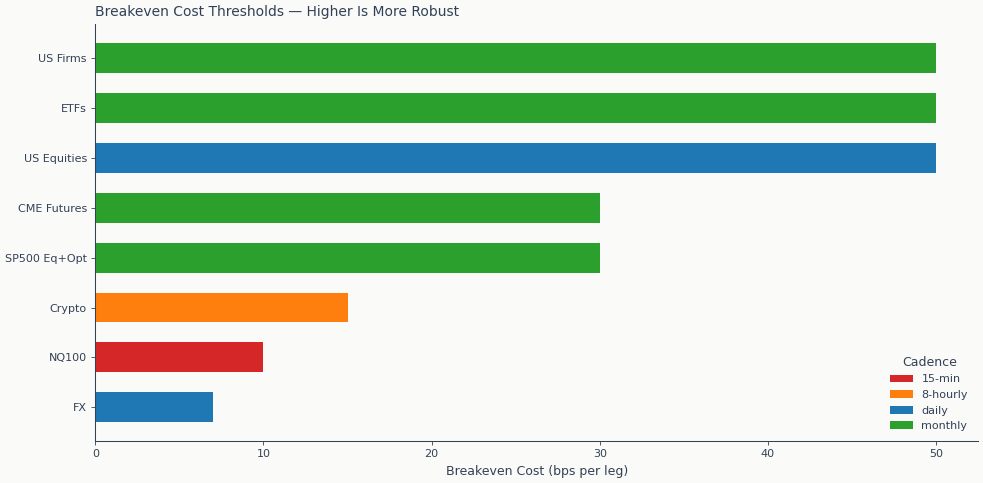

In [9]:
freq_order = ["15-min", "8-hourly", "daily", "monthly"]
freq_colors = {"15-min": "#d62728", "8-hourly": "#ff7f0e", "daily": "#1f77b4", "monthly": "#2ca02c"}

fig, ax = plt.subplots(figsize=(10, 5))

for i, row in enumerate(summary.sort("breakeven_bps").iter_rows(named=True)):
    cadence = row["cadence"]
    color = freq_colors.get(cadence, "gray")
    ax.barh(i, row["breakeven_bps"], color=color, height=0.6, edgecolor="none")

ax.set_yticks(range(len(summary)))
sorted_names = summary.sort("breakeven_bps")["display_name"].to_list()
ax.set_yticklabels(sorted_names)
ax.set_xlabel("Breakeven Cost (bps per leg)")
ax.set_title("Breakeven Cost Thresholds — Higher Is More Robust")

legend_handles = [Patch(facecolor=freq_colors[f], label=f) for f in freq_order if f in freq_colors]
ax.legend(handles=legend_handles, loc="lower right", title="Cadence")

fig.tight_layout()
fig.show()

## Cost Drag Curves

For each case study, plot Sharpe ratio as a function of per-leg
cost. This reveals the "cost cliff" — the point where a profitable
strategy becomes unprofitable.

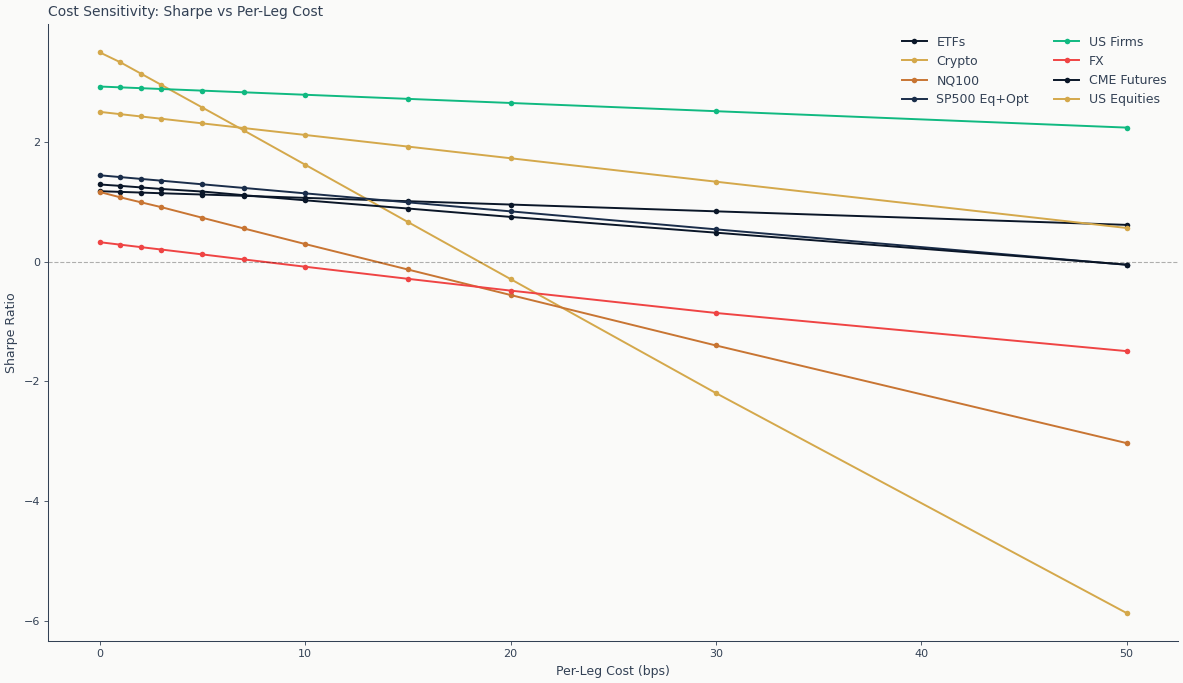

In [10]:
best_alloc_map = dict(
    zip(best_alloc["case_study"].to_list(), best_alloc["allocator"].to_list(), strict=False)
)

fig, ax = plt.subplots(figsize=(12, 7))

for cs_id in CS_LIST:
    alloc = best_alloc_map.get(cs_id)
    if alloc is None:
        continue

    cs_data = costs_df.filter(
        (pl.col("case_study") == cs_id) & (pl.col("allocator") == alloc)
    ).sort("cost_bps")

    if cs_data.is_empty():
        continue

    ax.plot(
        cs_data["cost_bps"].to_list(),
        cs_data["sharpe"].to_list(),
        marker="o",
        markersize=4,
        label=SHORT_NAMES.get(cs_id, cs_id),
    )

ax.axhline(y=0, color="black", linestyle="--", alpha=0.3, linewidth=0.8)
ax.set_xlabel("Per-Leg Cost (bps)")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Cost Sensitivity: Sharpe vs Per-Leg Cost")
ax.legend(loc="upper right", fontsize=9, ncol=2)

fig.tight_layout()
fig.show()

## Cost Survival Classification

Each case study is classified by cost resilience: the ratio of its breakeven
to the per-leg cost it is actually assumed to pay (Table 20.7), not to the
grid's smallest step. A higher ratio means more headroom once realistic
frictions are imposed. Per-share regimes (ETFs, NASDAQ) use a bps-equivalent
anchor — ETFs a ~2 bps half-spread, NASDAQ the 10 bps measured-spread
protocol point.

In [11]:
# Assumed per-leg cost (bps) in each carrier's signal/allocation stage,
# from Table 20.7 / the Ch18 cost-model decisions.
ASSUMED_COST_BPS = {
    "etfs": 2.0,
    "crypto_perps_funding": 4.0,
    "nasdaq100_microstructure": 10.0,
    "sp500_equity_option_analytics": 6.5,
    "us_firm_characteristics": 12.5,
    "fx_pairs": 4.0,
    "cme_futures": 10.0,
    "us_equities_panel": 12.5,
}

survival = (
    summary.with_columns(
        assumed_cost_bps=pl.col("case_study").replace_strict(
            ASSUMED_COST_BPS, default=1.0, return_dtype=pl.Float64
        ),
    )
    .with_columns(
        cost_margin_bps=(pl.col("breakeven_bps") - pl.col("assumed_cost_bps")),
        cost_margin_ratio=(
            pl.col("breakeven_bps") / pl.col("assumed_cost_bps").clip(lower_bound=1)
        ),
    )
    .with_columns(
        resilience=pl.when(pl.col("cost_margin_ratio") >= 10)
        .then(pl.lit("very robust"))
        .when(pl.col("cost_margin_ratio") >= 3)
        .then(pl.lit("robust"))
        .when(pl.col("cost_margin_ratio") >= 1.5)
        .then(pl.lit("marginal"))
        .otherwise(pl.lit("fragile")),
    )
)

print("=== Cost Survival Classification ===")
survival.select(
    "display_name",
    "cadence",
    "net_sharpe",
    "assumed_cost_bps",
    "breakeven_bps",
    "cost_margin_ratio",
    "resilience",
)

=== Cost Survival Classification ===


display_name,cadence,net_sharpe,assumed_cost_bps,breakeven_bps,cost_margin_ratio,resilience
str,str,f64,f64,i64,f64,str
"""FX""","""daily""",0.283,4.0,7,1.75,"""marginal"""
"""NQ100""","""15-min""",1.074,10.0,10,1.0,"""fragile"""
"""Crypto""","""8-hourly""",3.332,4.0,15,3.75,"""robust"""
"""SP500 Eq+Opt""","""monthly""",1.412,6.5,30,4.615385,"""robust"""
"""CME Futures""","""monthly""",1.266,10.0,30,3.0,"""robust"""
"""US Equities""","""daily""",2.464,12.5,50,4.0,"""robust"""
"""ETFs""","""monthly""",1.165,2.0,50,25.0,"""very robust"""
"""US Firms""","""monthly""",2.912,12.5,50,4.0,"""robust"""


## S&P 500 Options: Spread Realism Caveat

The S&P 500 Options case study was validated using executable-label
backtesting — pricing straddle entries and exits at actual bid/ask quotes
rather than assumed bps costs. The numbers are decisive:

- **Median round-trip spread**: 1091 bps of premium (10.9%)
- **Best executable Sharpe**: −1.05 (across 5 predictions × 8 schemes)
- **Three-label decomposition** (best GBM, `leaves_15_mae`, `ew_top5`):
  mid-unhedged Sharpe = +2.70, mid-DH Sharpe = +0.43, executable Sharpe = −1.50
- **Spread-adjusted ranking** (optimizing signal + spread jointly) improves
  Sharpe from −1.50 to −0.30, but stays negative

The ML signal is real (IC = 0.068), but the 15.4 pp average spread impact
per trade overwhelms the per-period signal. A generic bps cost sweep
misrepresents this case study because the cost is predominantly the
bid-ask spread, not commission. The teaching point is that strategy
design must jointly optimize for signal quality and execution costs:
single-stock option spreads are the binding constraint, not model
quality.

## Cadence–Frequency–Cost Regime

The same IC translates to very different tradability depending on
rebalance cadence. A 15-minute strategy accumulates ~25× more turnover
per day than a daily strategy, and ~500× more than a monthly one.
This creates distinct cost regimes:

In [12]:
if not summary.is_empty():
    freq_to_turnover_multiplier = {
        "15-min": 26.0,
        "8-hourly": 3.0,
        "daily": 1.0,
        "monthly": 1.0 / 21,
    }

    regime = summary.with_columns(
        turnover_mult=pl.col("cadence").replace_strict(
            freq_to_turnover_multiplier,
            default=1.0,
            return_dtype=pl.Float64,
        ),
    )

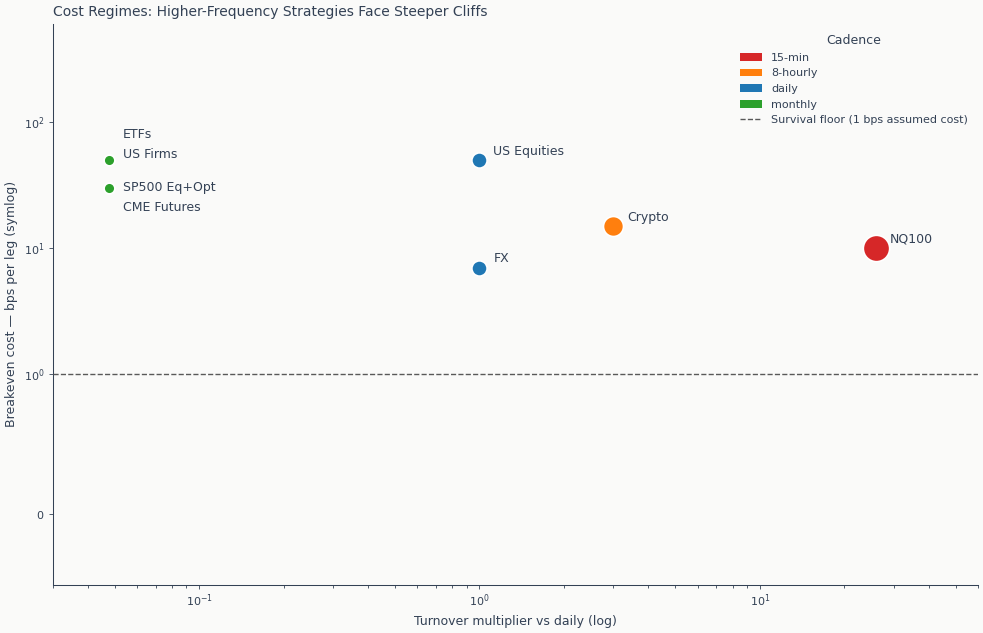

In [13]:
if not summary.is_empty():
    fig, ax = plt.subplots(figsize=(10, 6.5))

    # Turnover-mult on x (varies 0.05→26×); breakeven on y. Both log so the
    # high-frequency cluster (NQ100/Crypto) and the monthly cluster
    # separate cleanly instead of stacking on a constant-x degenerate column.
    assumed_floor = max(float(summary["assumed_cost_bps"].min()), 0.5)

    # Monthly carriers share x (turnover ≈ 0.05) and pair up on y: ETFs and
    # US Firms at 50, CME and SP500 Eq+Opt at 30. Fan their labels vertically
    # so the two pairs stay legible despite the superimposed markers.
    label_offsets = {
        "NQ100": (10, 4),
        "Crypto": (10, 4),
        "FX": (10, 4),
        "US Equities": (10, 4),
        "ETFs": (10, 16),
        "US Firms": (10, 2),
        "SP500 Eq+Opt": (10, -2),
        "CME Futures": (10, -16),
        "SP500 Options": (10, 4),
    }

    for row in regime.iter_rows(named=True):
        color = freq_colors.get(row["cadence"], "gray")
        size = max(60, min(360, row["turnover_mult"] ** 0.5 * 120))
        ax.scatter(
            row["turnover_mult"],
            max(row["breakeven_bps"], 0.5),
            s=size,
            c=color,
            edgecolors="white",
            linewidth=1.2,
            zorder=5,
        )
        dx, dy = label_offsets.get(row["display_name"], (8, 8))
        ax.annotate(
            row["display_name"],
            (row["turnover_mult"], max(row["breakeven_bps"], 0.5)),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=9,
            zorder=6,
        )

    ax.axhline(
        assumed_floor,
        color="0.35",
        linestyle="--",
        linewidth=1.0,
        zorder=3,
        label=f"Survival floor ({assumed_floor:.0f} bps assumed cost)",
    )
    ax.set_xscale("log")
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlim(0.03, 60)
    ax.set_ylim(-0.5, 600)

    ax.set_xlabel("Turnover multiplier vs daily (log)")
    ax.set_ylabel("Breakeven cost — bps per leg (symlog)")
    ax.set_title("Cost Regimes: Higher-Frequency Strategies Face Steeper Cliffs")

    legend_handles = [
        Patch(facecolor=freq_colors[f], label=f) for f in freq_order if f in freq_colors
    ]
    ax.legend(
        handles=legend_handles + [ax.get_lines()[0]],
        loc="upper right",
        title="Cadence",
        framealpha=0.9,
    )

    fig.tight_layout()
    fig.show()

**Interpretation**: Marker x-position is per-day turnover relative to a daily
strategy (15-min ≈ 26×, 8-hourly ≈ 3×, monthly ≈ 0.05×); marker y is the
breakeven cost at which the strategy's net Sharpe crosses zero. Strategies
above the dashed survival floor (assumed cost ≈ 1 bps per leg) survive their
cost model; those below do not. Three regimes emerge:

- **High-frequency** (NQ-100, Crypto): the steepest cost gradients, set by
  turnover. NQ-100's marginal gross (+1.16) breaks even at ~10 bps — right at
  its measured-spread cost, the thinnest headroom in the test bed (fragile).
  Crypto's stronger gross (+3.5) reaches 15 bps, a comfortable multiple of its
  3-to-4 bps schedule despite the 8-hourly cadence.
- **Daily, signal-dependent** (FX, US Equities): FX breaks even at ~7 bps,
  only a couple of basis points above its assumed spread (marginal), while
  US Equities' stronger signal carries it through the whole grid — survival
  here is set by signal strength, not cadence alone.
- **Monthly, robust** (CME and SP500 Eq+Opt ≈ 30 bps; ETFs and US Firms to
  the 50-bps ceiling): low turnover leaves wide margins, though US Firms'
  binding constraint is universe liquidity (bottom-quartile spreads of
  100–500 bps), not the swept per-leg cost.

SP500 Options is excluded from the "monthly robust" category because
executable-label backtesting at actual bid/ask prices shows best
Sharpe = −1.05.

## Key Takeaways

1. **Frequency is the dominant cost driver**. Higher-frequency strategies
   (15-min, 8-hourly) face structurally higher turnover and need wider
   cost budgets to survive.
2. **Monthly strategies are most robust**. Monthly rebalance cadences
   (ETFs, CME, US Firms) have the widest breakeven margins because
   turnover per period is inherently lower.
3. **Cost cliffs are steep**. Most strategies show a sharp drop from
   profitable to unprofitable within a narrow cost range — the difference
   between a 5-bps and 15-bps execution cost can determine viability.
4. **Cost structure matters as much as signal**. A strong signal in a
   high-cost asset class may underperform a weaker signal in a low-cost
   asset class after realistic costs.
5. **Generic bps sweeps can mislead**. SP500 Options demonstrates that
   when the dominant cost is the bid-ask spread (median RT 1091 bps),
   a basis-point sensitivity grid understates the cost. Executable
   backtesting against actual quotes is the right test for those cases.

**Next**: [`07_regime_risk`](07_regime_risk.ipynb) examines regime
robustness and risk overlays.